In [1]:
import sys
from pathlib import Path

# add project root to Python path
ROOT = Path("..").resolve()
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

In [2]:
import numpy as np
from pathlib import Path

from src.processes import Mess3Component, sample_sequence, sample_balanced_mixture_dataset, split_by_sequence
from src.beliefs import compute_beliefs_for_sequence, compute_beliefs_for_dataset

rng = np.random.default_rng(0)
Path("../outputs/data").mkdir(parents=True, exist_ok=True)
Path("../outputs/plots").mkdir(parents=True, exist_ok=True)
Path("../outputs/checkpoints").mkdir(parents=True, exist_ok=True)

In [3]:
import numpy as np
from src.processes import Mess3Component

def make_mess3_component(name: str, component_id: int, x: float, alpha: float):
    assert 0.0 <= x <= 0.5
    assert 0.0 <= alpha <= 1.0

    K = 3
    V = 3

    pi = np.array([1/3, 1/3, 1/3], dtype=np.float64)

    A = np.full((K, K), x, dtype=np.float64)
    np.fill_diagonal(A, 1 - 2 * x)

    E = np.full((K, V), (1 - alpha) / 2, dtype=np.float64)
    for i in range(K):
        E[i, i] = alpha

    comp = Mess3Component(
        name=name,
        component_id=component_id,
        pi=pi,
        A=A,
        E=E,
        vocab_size=V,
    )
    comp.validate()
    return comp

components = [
    make_mess3_component("mess3_c0_x005_a085", 0, x=0.05, alpha=0.85),
    make_mess3_component("mess3_c1_x010_a085", 1, x=0.10, alpha=0.85),
    make_mess3_component("mess3_c2_x005_a075", 2, x=0.05, alpha=0.75),
]

components_by_id = {c.component_id: c for c in components}

for c in components:
    print(c.name)
    print("pi =", c.pi)
    print("A =\n", c.A)
    print("E =\n", c.E)
    print("A row sums:", c.A.sum(axis=1))
    print("E row sums:", c.E.sum(axis=1))
    print()

mess3_c0_x005_a085
pi = [0.33333333 0.33333333 0.33333333]
A =
 [[0.9  0.05 0.05]
 [0.05 0.9  0.05]
 [0.05 0.05 0.9 ]]
E =
 [[0.85  0.075 0.075]
 [0.075 0.85  0.075]
 [0.075 0.075 0.85 ]]
A row sums: [1. 1. 1.]
E row sums: [1. 1. 1.]

mess3_c1_x010_a085
pi = [0.33333333 0.33333333 0.33333333]
A =
 [[0.8 0.1 0.1]
 [0.1 0.8 0.1]
 [0.1 0.1 0.8]]
E =
 [[0.85  0.075 0.075]
 [0.075 0.85  0.075]
 [0.075 0.075 0.85 ]]
A row sums: [1. 1. 1.]
E row sums: [1. 1. 1.]

mess3_c2_x005_a075
pi = [0.33333333 0.33333333 0.33333333]
A =
 [[0.9  0.05 0.05]
 [0.05 0.9  0.05]
 [0.05 0.05 0.9 ]]
E =
 [[0.75  0.125 0.125]
 [0.125 0.75  0.125]
 [0.125 0.125 0.75 ]]
A row sums: [1. 1. 1.]
E row sums: [1. 1. 1.]



In [4]:
from src.processes import sample_sequence

rng = np.random.default_rng(0)

for comp in components:
    print("==", comp.name, "==")
    for _ in range(3):
        tokens, states = sample_sequence(comp, seq_len=16, rng=rng)
        print("states:", states)
        print("tokens:", tokens)
    print()

== mess3_c0_x005_a085 ==
states: [1 0 0 0 0 0 0 0 0 0 0 0 0 2 2 2]
tokens: [1 0 1 0 2 0 0 0 0 0 0 0 0 2 2 2]
states: [0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1]
tokens: [0 0 1 1 1 1 1 1 1 1 0 1 1 0 1 1]
states: [0 0 0 0 0 0 0 1 1 1 1 1 1 1 0 2]
tokens: [0 2 0 2 2 0 2 1 1 1 1 2 1 2 1 2]

== mess3_c1_x010_a085 ==
states: [0 1 1 1 1 1 0 0 0 0 2 2 2 2 2 2]
tokens: [2 1 1 1 1 2 0 0 0 0 0 0 2 2 2 2]
states: [0 0 1 1 1 2 2 2 2 0 0 0 0 0 2 2]
tokens: [0 0 1 1 1 2 2 1 2 0 0 0 0 0 1 0]
states: [1 1 1 1 1 1 1 1 1 2 2 1 1 1 1 1]
tokens: [1 2 1 1 1 2 1 1 2 2 2 1 1 1 1 1]

== mess3_c2_x005_a075 ==
states: [1 2 0 2 2 2 2 2 2 2 1 1 1 1 1 1]
tokens: [0 2 1 2 1 1 2 0 2 2 1 1 1 1 1 0]
states: [2 2 2 2 2 1 1 1 1 1 1 1 1 1 2 2]
tokens: [2 1 2 2 2 1 1 2 2 1 1 2 1 1 2 2]
states: [2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2]
tokens: [0 2 2 1 2 0 0 2 2 2 2 2 2 2 2 2]



In [5]:
def quick_stats(tokens_batch, states_batch):
    same_state = (states_batch[:, 1:] == states_batch[:, :-1]).mean()
    token_match = (tokens_batch == states_batch).mean()
    return same_state, token_match

for comp in components:
    toks = []
    sts = []
    for _ in range(2000):
        t, s = sample_sequence(comp, seq_len=32, rng=rng)
        toks.append(t)
        sts.append(s)
    toks = np.stack(toks)
    sts = np.stack(sts)

    same_state, token_match = quick_stats(toks, sts)
    print(comp.name)
    print("empirical P(same next state):", round(float(same_state), 3))
    print("empirical P(token == state): ", round(float(token_match), 3))
    print()

mess3_c0_x005_a085
empirical P(same next state): 0.899
empirical P(token == state):  0.851

mess3_c1_x010_a085
empirical P(same next state): 0.801
empirical P(token == state):  0.849

mess3_c2_x005_a075
empirical P(same next state): 0.899
empirical P(token == state):  0.747



In [6]:
from src.beliefs import compute_beliefs_for_sequence

comp = components[0]

tokens, states = sample_sequence(comp, seq_len=10, rng=rng)

beliefs = compute_beliefs_for_sequence(tokens, comp.pi, comp.A, comp.E)

print("tokens:", tokens)
print("states:", states)
print()

print("filtered beliefs P(z_t | x_≤t):")
print(np.round(beliefs["filtered_after_obs"], 3))
print()

print("predictive next beliefs P(z_{t+1} | x_≤t):")
print(np.round(beliefs["predictive_next"], 3))
print()

print("row sums filtered:", beliefs["filtered_after_obs"].sum(axis=1))
print("row sums predictive_next:", beliefs["predictive_next"].sum(axis=1))
print("loglik:", beliefs["loglik"])

tokens: [2 1 1 0 2 2 0 0 0 0]
states: [2 1 1 2 2 2 2 0 0 0]

filtered beliefs P(z_t | x_≤t):
[[0.075 0.075 0.85 ]
 [0.052 0.593 0.355]
 [0.014 0.934 0.052]
 [0.428 0.514 0.058]
 [0.205 0.241 0.555]
 [0.035 0.04  0.925]
 [0.496 0.046 0.458]
 [0.91  0.015 0.075]
 [0.981 0.007 0.012]
 [0.989 0.005 0.006]]

predictive next beliefs P(z_{t+1} | x_≤t):
[[0.114 0.114 0.772]
 [0.094 0.554 0.352]
 [0.062 0.844 0.094]
 [0.414 0.487 0.099]
 [0.224 0.255 0.521]
 [0.08  0.084 0.836]
 [0.471 0.089 0.44 ]
 [0.823 0.063 0.114]
 [0.884 0.056 0.06 ]
 [0.89  0.055 0.055]]

row sums filtered: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
row sums predictive_next: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
loglik: -11.735296949192236


In [7]:
import itertools
import numpy as np
import matplotlib.pyplot as plt

from src.beliefs import compute_beliefs_for_sequence


def enumerate_prefix_beliefs(component, max_len=8, use="filtered_after_obs"):
    """
    Enumerate all token prefixes of lengths 1..max_len and compute beliefs.
    
    Returns:
        prefixes: list of tuples
        beliefs: np.ndarray [num_prefixes, 3]
        lengths: np.ndarray [num_prefixes]
    """
    prefixes = []
    beliefs = []
    lengths = []

    vocab = list(range(component.vocab_size))

    for L in range(1, max_len + 1):
        for prefix in itertools.product(vocab, repeat=L):
            prefix = np.array(prefix, dtype=np.int64)
            out = compute_beliefs_for_sequence(prefix, component.pi, component.A, component.E)
            b = out[use][-1]   # belief after full prefix
            prefixes.append(tuple(prefix.tolist()))
            beliefs.append(b)
            lengths.append(L)

    return prefixes, np.array(beliefs), np.array(lengths)


def simplex_to_2d(beliefs):
    """
    Map 3-state belief vectors [p0,p1,p2] to 2D coordinates in an equilateral triangle.
    Vertices:
      state 0 -> (0,0)
      state 1 -> (1,0)
      state 2 -> (0.5, sqrt(3)/2)
    """
    v0 = np.array([0.0, 0.0])
    v1 = np.array([1.0, 0.0])
    v2 = np.array([0.5, np.sqrt(3) / 2.0])

    xy = (
        beliefs[:, [0]] * v0
        + beliefs[:, [1]] * v1
        + beliefs[:, [2]] * v2
    )
    return xy


def draw_simplex(ax):
    tri = np.array([
        [0.0, 0.0],
        [1.0, 0.0],
        [0.5, np.sqrt(3) / 2.0],
        [0.0, 0.0],
    ])
    ax.plot(tri[:, 0], tri[:, 1], linewidth=1.5)
    ax.text(-0.03, -0.04, "state 0", fontsize=10)
    ax.text(1.01, -0.04, "state 1", fontsize=10, ha="left")
    ax.text(0.5, np.sqrt(3)/2 + 0.03, "state 2", fontsize=10, ha="center")
    ax.set_aspect("equal")
    ax.set_xlim(-0.08, 1.08)
    ax.set_ylim(-0.08, np.sqrt(3)/2 + 0.08)
    ax.axis("off")

C:\Users\nikak\AppData\Local\Temp\ipykernel_10212\1916839862.py:34: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


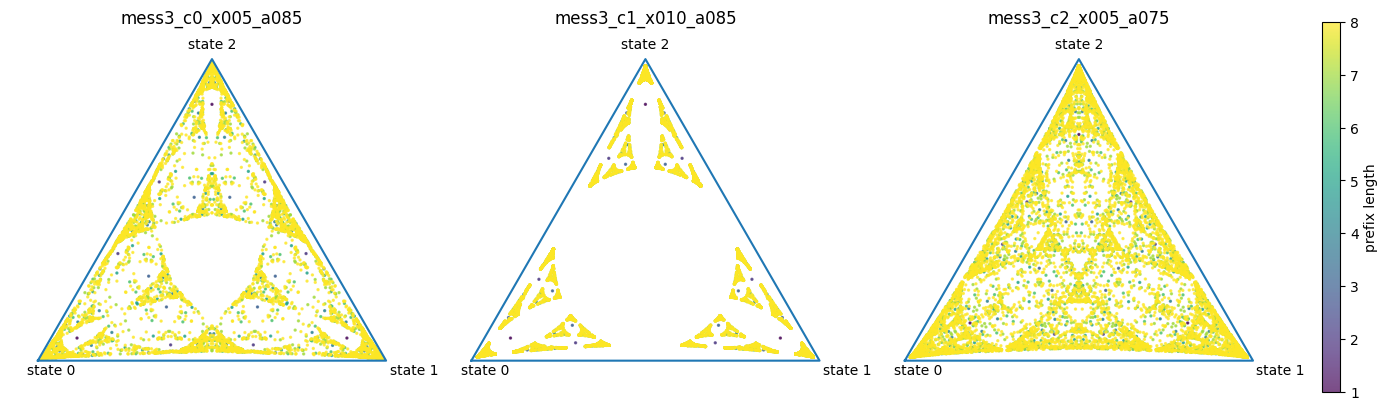

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))

for ax, comp in zip(axes, components):
    prefixes, beliefs, lengths = enumerate_prefix_beliefs(
        comp,
        max_len=8,
        use="filtered_after_obs",
    )
    xy = simplex_to_2d(beliefs)

    draw_simplex(ax)

    sc = ax.scatter(
        xy[:,0],
        xy[:,1],
        c=lengths,
        cmap="viridis",
        s=2,
        alpha=0.7,
    )

    ax.set_title(comp.name)

cbar = fig.colorbar(
    sc,
    ax=axes,
    location="right",
    fraction=0.02,
    pad=-0.17
)

cbar.set_label("prefix length")

plt.tight_layout()
plt.show()